# 11주차_머신러닝 분석 방법론 Ⅱ

- 서포트벡터머신(분류 모델)

---

In [ ]:
# 필요한 패키지 설치

from sklearn.preprocessing import MinMaxScaler
# 입력 데이터의 스케일을 0과 1 사이로 정규화하기 위한 정규화 도구 불러오기
# MinMaxScaler는 각 피처의 최소값과 최대값을 기준으로 선형 변환을 수행함
# 정규화는 피처 간 단위 차이를 제거하여 SVM과 같은 거리 기반 알고리즘의 성능을 향상시키는 전처리 과정임

from sklearn.model_selection import train_test_split
# 전체 데이터를 학습셋과 테스트셋으로 나누기 위한 함수 불러오기
# 모델의 성능을 검증하기 위해 독립적인 평가 데이터셋을 확보하는 목적임

import sklearn.svm as svm
# scikit-learn의 SVM(support vector machine) 관련 하위 모듈을 전체적으로 불러오기
# SVC 외에도 NuSVC, SVR, LinearSVC 등 다양한 SVM 기반 모델 객체에 접근 가능하게 설정함

from sklearn.svm import SVC
# 분류용 서포트 벡터 머신(Support Vector Classification) 모델 클래스인 SVC만 별도로 불러오기
# SVC는 커널 트릭(kernel trick)을 활용해 선형 및 비선형 분류 문제 모두에 대응 가능한 SVM 구현체임

import pandas as pd
# 데이터프레임 형태의 구조화된 데이터를 다루기 위한 pandas 라이브러리 불러오기
# 데이터 로딩, 전처리, 분석 및 시각화 전 단계에서 기본적인 데이터 처리 도구로 활용됨


In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/muratkokludataset/raisin-dataset
df = pd.read_excel("datasets/Raisin_Dataset.xlsx")

# 데이터 샘플 확인
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
# 독립변수 정규화

# 독립변수, 종속변수 분리
df_x = df.drop(['Area', 'Class'], axis=1)
# 'Area'와 'Class' 열을 제외한 나머지 피처들만 추출하여 df_x에 저장함
# 'Area'는 제거 대상이므로 분석에서 제외하며, 'Class'는 종속변수이므로 분리함
# 결과적으로 df_x에는 정규화 대상이 될 수치형 독립변수들만 남게 됨

df_y = df[['Class']]
# 종속변수인 'Class' 열만 추출하여 df_y에 저장함
# 이 열은 건포도의 품종(Kecimen 또는 Besni)을 의미하며, 분류 모델의 타겟 레이블 역할을 수행함
# DataFrame 형태로 추출하여 후속 모델링 작업에서 인덱스 정렬을 유지함

# 데이터 정규화 적용
MinMaxScaler = MinMaxScaler()
# scikit-learn의 MinMaxScaler 객체를 생성함
# 각 독립변수를 [0, 1] 범위로 선형 변환하여 정규화하기 위한 도구임
# 변수 간 스케일 차이로 인해 발생하는 학습 편향을 줄이기 위한 전처리 단계임

df_minmax = MinMaxScaler.fit_transform(df_x)
# df_x의 각 피처에 대해 정규화를 수행함
# fit()은 각 피처의 최소값과 최대값을 학습하고, transform()은 이를 기준으로 0~1 사이의 값으로 변환함
# 반환 결과는 NumPy 배열(ndarray) 형식으로 제공됨

# 컬럼명 결합
df_x = pd.DataFrame(data=df_minmax, columns=df_x.columns)
# 정규화된 데이터를 다시 pandas DataFrame 형태로 변환함
# 원래 df_x의 컬럼명을 그대로 사용하여 해석 가능한 구조로 복원함
# 이후 분석이나 시각화 시 변수 이름을 유지하는 목적임

df_x.head()
# 정규화된 독립변수들의 상위 5개 행을 출력함
# 데이터 변환 결과를 시각적으로 확인하고, 값의 범위가 0~1로 잘 조정되었는지 점검하는 절차임


,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,0.280714,0.314376,0.767872,0.255504,0.831422,0.271791
1,0.234638,0.284945,0.738636,0.208864,0.667854,0.241842
2,0.280741,0.351778,0.733009,0.268084,0.565754,0.283594
3,0.078935,0.186620,0.548194,0.084089,0.701809,0.108284
4,0.164011,0.422064,0.350968,0.219472,0.906315,0.218493


In [ ]:
# 학습셋과 테스트셋 분리하여 생성(6:4)

x_train, x_test, y_train, y_test = train_test_split(
    df_x, df_y, test_size=0.4, random_state=10)
# 전체 데이터(df_x, df_y)를 학습셋과 테스트셋으로 분할함
# test_size=0.4는 전체 샘플 중 40%를 테스트셋으로 할당하고, 나머지 60%를 학습셋으로 사용함
# random_state=10은 데이터 분할을 무작위로 수행하되 재현 가능하도록 시드를 고정함
# 이 분할은 모델 훈련과 성능 평가를 독립적으로 수행하기 위한 전처리 단계임

# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(x_train))
# 학습셋에 포함된 샘플 개수를 출력함
# 데이터 분할이 정상적으로 이루어졌는지, 비율이 기대에 부합하는지를 확인하는 절차임

print('test data 개수: ', len(x_test))
# 테스트셋에 포함된 샘플 개수를 출력함
# 학습 대비 테스트셋의 비율과 샘플 수의 적절성을 검증하는 단계임


train data 개수:  540
test data 개수:  360


In [ ]:
# ✅ 선형 SVM(Support Vector Machine) 이해를 위한 핵심 개념 정리

# ▶ 1. 목적
# SVM의 핵심 목적은 서로 다른 두 클래스를 가장 **넓은 여유(margin)**를 두고 분리하는 **결정 경계(hyperplane)**를 찾는 것임
# 이렇게 하면 새로운 데이터에 대해서도 **일반화 성능**이 좋은 모델을 만들 수 있음

# ▶ 2. 결정 경계의 수학적 정의
# 선형 SVM이 찾는 결정 경계는 다음과 같은 수식으로 표현됨:
# f(x) = w1 * x1 + w2 * x2 + ... + wn * xn + b = w · x + b
# 여기서,
# - x는 입력 피처 벡터
# - w는 각 피처에 대한 가중치 벡터
# - b는 절편(바이어스) 값임

# ▶ 3. 분류 기준
# 위 식의 결과가 0보다 크면 양성 클래스(+1), 작으면 음성 클래스(-1)로 분류함
# 즉, 결정 경계는 "w · x + b = 0"을 만족하는 직선 또는 초평면임

# ▶ 4. 마진(Margin)
# 마진은 결정 경계와 **각 클래스의 가장 가까운 데이터 포인트(서포트 벡터)** 사이의 거리임
# 선형 SVM은 이 마진을 가능한 한 **최대화**하는 방향으로 w와 b를 학습함

# 마진의 수식 표현:
# margin = 2 / ||w||
# → ||w||는 벡터 w의 L2 노름(norm), 즉 w의 크기를 의미함

# ▶ 5. 서포트 벡터(Support Vector)
# 결정 경계에 **가장 가까운 위치에 있는 샘플**을 서포트 벡터라고 함
# 이 점들만이 경계에 영향을 주며, 나머지 점은 전혀 영향을 미치지 않음
# SVM은 이런 점들만 사용하여 모델을 정의하는 **희소 모델(sparse model)**임

# ▶ 6. 최적화 문제 (Soft Margin SVM)
# 모든 샘플이 완벽하게 분리되지 않는 경우를 고려해, SVM은 다음과 같은 **최적화 문제**를 풀게 됨:

# Minimize:   0.5 * ||w||^2 + C * Σξ_i  
# Subject to: y_i * (w · x_i + b) ≥ 1 - ξ_i   for all i  
#             ξ_i ≥ 0

# 여기서,
# - y_i는 정답 레이블 (+1 또는 -1)
# - ξ_i는 슬랙 변수(slack variable)로 마진 위반 허용량
# - C는 규제 파라미터로, 마진 폭과 오분류에 대한 균형을 조절하는 하이퍼파라미터임

# ▶ 7. C 파라미터의 역할
# C 값이 작을수록 → 마진은 넓고 오분류를 허용함 → **일반화 성능은 좋으나 과소적합 가능**
# C 값이 클수록 → 마진을 좁게 하여 오분류를 거의 허용하지 않음 → **학습셋 정확도는 높지만 과적합 위험**

# ▶ 8. 정리
# - 선형 SVM은 선형 결정 경계를 찾는 분류 알고리즘임
# - 마진을 최대화함으로써 오버피팅을 줄이고 일반화 성능을 높이려 함
# - 서포트 벡터만으로 결정 경계를 정의하는 효율적인 모델임
# - 실제 구현은 커널을 통해 비선형 SVM으로도 확장 가능함 (선형 SVM은 kernel='linear'일 때임)

# -----------------------------------------------------------------------------

# 선형 SVM 모델 성능 확인

# 3차항(degree), 학습 반복횟수(max_iter) 10000 설정
svm_model = SVC(kernel='linear', degree=3, gamma='auto', C=10, max_iter=1000)
# SVC(Support Vector Classification) 클래스의 객체를 생성함
# kernel='linear'은 선형 커널을 사용하여 직선(또는 초평면) 형태의 결정 경계를 학습하도록 지정함
# degree=3은 다항 커널일 때만 사용되는 옵션이며, 선형 커널에는 영향을 미치지 않음
# gamma='auto'는 감마 값을 특성 수의 역수로 설정함 (선형 커널에서는 무시됨)
# C=10은 규제 파라미터로, 오차를 얼마나 허용할지를 제어함 → 값이 클수록 과적합 경향이 강해짐
# max_iter=1000은 학습 반복 횟수의 최대값을 1000번으로 제한함 → 수렴하지 않을 경우 조기 종료됨

svm_model.fit(x_train, y_train)
# 훈련 데이터(x_train, y_train)를 이용해 SVM 모델을 학습시킴
# 목적 함수는 마진을 최대화하면서 오분류를 최소화하는 초평면을 찾는 것임
# 이 과정에서 최적의 서포트 벡터와 경계면을 계산함

print(svm_model.score(x_train, y_train))
# 학습 데이터에 대해 예측 정확도를 계산하여 출력함
# 내부적으로 `.predict()`를 수행한 결과와 y_train을 비교하여 정확도를 반환함
# 훈련셋 기준의 성능으로, 모델이 훈련 데이터에 잘 적합되었는지를 확인하는 용도임

print(svm_model.score(x_test, y_test))
# 테스트 데이터에 대해 예측 정확도를 계산하여 출력함
# 모델의 일반화 성능, 즉 새로운 데이터에 대한 예측 능력을 평가하기 위한 지표임


0.8648148148148148
0.8638888888888889


C:\Users\angry\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# SVM C값 1~30에 따른 모델 성능 확인

scores = []
# 학습 정확도와 테스트 정확도를 저장할 리스트 초기화
# 이후 C 값에 따라 반복적으로 측정된 정확도들을 순차적으로 저장함

for C_point in [*range(1, 31)]:
    # C 값을 1부터 30까지 1씩 증가시키며 반복하는 for 루프 정의
    # C는 SVM의 규제(regularization) 강도를 제어하는 하이퍼파라미터임
    # 값이 작을수록 마진을 넓게 하고 오분류를 더 허용하며, 값이 클수록 마진보다 정확도를 우선하여 과적합될 수 있음
    # (C가 클수록 오분류를 덜 허용함 → 복잡한 경계 생성 → 과적합 위험 증가)

    svc = SVC(kernel='rbf', C=C_point, max_iter=1000)
    # RBF(Radial Basis Function) 커널을 사용하는 SVC 객체 생성
    # C는 반복 중 현재 루프에서 사용할 규제 값이며, max_iter=1000은 최대 학습 반복 횟수를 제한함
    # RBF 커널은 데이터가 선형적으로 구분되지 않을 때 비선형 결정 경계를 생성하기 위한 커널임

    C_model = svc.fit(x_train, y_train)
    # 학습 데이터를 사용해 SVM 모델을 학습시킴
    # 결과적으로 C 값에 따라 각기 다른 결정 경계가 학습되며, 모델 복잡도도 변화함

    train_score = C_model.score(x_train, y_train)
    # 학습 데이터에 대한 정확도를 계산하여 train_score 변수에 저장함
    # 해당 정확도는 현재 C 값에서 모델이 훈련 데이터에 얼마나 잘 적합되었는지를 나타냄

    test_score = C_model.score(x_test, y_test)
    # 테스트 데이터에 대한 정확도를 계산하여 test_score 변수에 저장함
    # 일반화 성능(새로운 데이터에 대한 예측력)을 확인하기 위한 지표임

    print("rbf SVM : C:{}, train set score:{:2f}, test set score:{:2f}".format
          (C_point, train_score, test_score))
    # 현재 C 값에서의 학습셋 정확도와 테스트셋 정확도를 형식화된 문자열로 출력함
    # 숫자값은 소수점 6자리까지 표현됨

    scores.append([train_score, test_score])
    # 두 정확도 값을 리스트 형태로 묶어 scores 리스트에 추가함
    # 이후 성능 비교를 위한 시각화 또는 분석 자료로 활용하기 위한 누적 저장 구조임


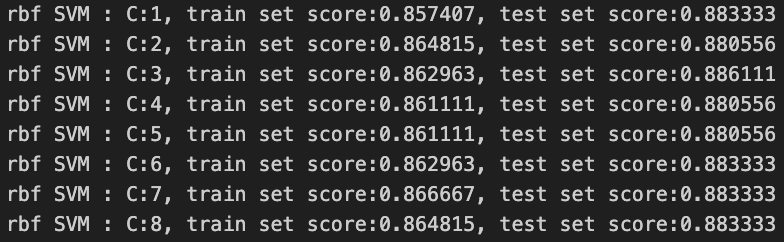

.
.
.
.

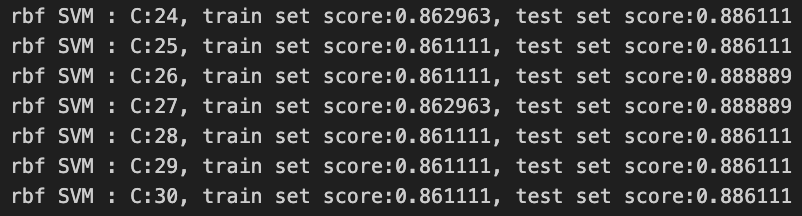

### 개념 요약: `C` 파라미터의 역할

- **C 값 작을 때 (예: C=1)**
    
    → 더 넓은 마진 허용, 오분류 일부 허용
    
    → **일반화 성능은 높고, 과적합 가능성은 낮음**
    
    → 경계가 부드럽고 단순함
    
- **C 값 클 때 (예: C=30)**
    
    → 오분류 거의 허용하지 않음, 마진 좁아짐
    
    → **학습셋 정확도는 높지만, 과적합 발생 가능성 증가**
    
    → 경계가 복잡해지고 노이즈에 민감해짐

In [ ]:
# SVM gamma값 1~30에 따른 모델 성능 확인

scores = []
# 학습 정확도와 테스트 정확도를 저장할 빈 리스트 초기화
# 각 gamma 값에 대한 결과를 순차적으로 누적 저장함

for gamma_point in [0.1, 0.5, 1, 5, 10, 20]:
    # RBF 커널에서 사용할 gamma 값을 반복함
    # gamma는 RBF 커널의 "곡률" 또는 "결정 경계의 유연성"을 조절하는 하이퍼파라미터임
    # gamma 값이 작을수록 경계가 부드러워지고, 클수록 경계가 날카롭고 과적합 경향을 띔

    svc = SVC(kernel='rbf', C=10, gamma=gamma_point, max_iter=1000)
    # RBF 커널 기반의 SVC 모델 생성
    # C=10은 규제 강도이며 고정된 상태로 gamma에 따른 영향을 비교함
    # max_iter=1000은 학습 반복 횟수를 1,000번으로 제한함

    model = svc.fit(x_train, y_train)
    # 학습 데이터를 이용해 현재 gamma 값을 기반으로 SVM 모델 학습 수행
    # 학습 결과는 각 클래스 간 비선형 경계를 생성하는 형태로 나타남

    train_score = model.score(x_train, y_train)
    # 학습 데이터에 대한 정확도를 계산함
    # 높은 정확도는 학습 데이터에 대한 과적합 여부를 판단하는 주요 지표임

    test_score = model.score(x_test, y_test)
    # 테스트 데이터에 대한 정확도를 계산함
    # 모델이 새로운 데이터에 대해 얼마나 일반화되었는지를 나타내는 핵심 지표임

    print("rbf SVM : gamma:{}, train set score:{:2f}, test set score:{:2f}".format
          (gamma_point, train_score, test_score))
    # 현재 gamma 값에서의 학습 정확도와 테스트 정확도를 화면에 출력함
    # 결과는 실험적으로 gamma 값이 모델 성능에 미치는 영향을 확인하기 위한 기준임

    scores.append([train_score, test_score])
    # 각 gamma 설정에 따른 학습 및 테스트 정확도를 리스트로 묶어 scores 리스트에 저장함
    # 이후 그래프 시각화나 비교 분석에 활용할 수 있음


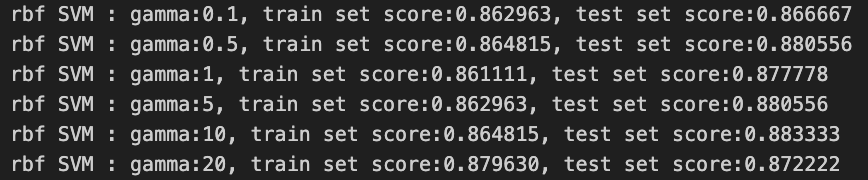

### 개념 요약: `gamma` 파라미터의 의미

| gamma 값 크기 | 의미 | 효과 |
| --- | --- | --- |
| 작을수록 (예: 0.1) | 커널 영향 범위가 큼 | 결정 경계가 부드러워짐 → 과소적합 가능성 |
| 클수록 (예: 10, 20) | 커널 영향 범위가 작음 | 결정 경계가 복잡해짐 → 과적합 위험 증가 |

> RBF 커널은 거리 기반으로 작동하며, gamma는 데이터 포인트 하나가 주변 공간에 미치는 영향 반경을 조절하는 역할임.
>

---

## SVM의 `C` vs `gamma` 비교

| 항목 | `C` (Regularization Parameter) | `gamma` (Kernel Coefficient for RBF, Poly, Sigmoid) |
| --- | --- | --- |
| **역할** | 오분류에 대한 **패널티 강도** 조절 | **커널 함수의 곡률** 및 **데이터 영향 범위** 조절 |
| **값이 작을 때** | 오차를 더 허용함 → **마진을 넓게** 설정 | 커널 영향 범위 넓어짐 → **결정 경계가 부드러움** |
| **값이 클 때** | 오차를 거의 허용하지 않음 → **마진 좁고 경계가 복잡해짐** | 커널 영향 범위 좁아짐 → **결정 경계가 날카롭고 과적합 위험** 증가 |
| **과적합 영향** | **C가 클수록 과적합** 가능성 증가 | **gamma가 클수록 과적합** 위험 증가 |
| **직관적 의미** | 얼마나 **틀려도 되는가?** (오분류에 대한 관용도) | 얼마나 **국소적으로 판단할 것인가?** (데이터 간 거리 민감도) |
| **적용 범위** | 모든 커널에 사용 가능 | RBF, Poly, Sigmoid 커널에만 적용됨 (Linear 커널에서는 사용되지 않음) |
| **공식적 정의** | `Minimize: 0.5 * |  |
| **추천 전략** | 데이터 노이즈가 많으면 **작게**, 과적합이 의심되면 **줄이기** | 낮은 차원 데이터는 **작게**, 고차원 비선형 데이터는 **점차 늘려가며 탐색하기** |



## 요약 인사이트

- `C`: **전체적인 모델의 규제 강도**
    
    → 클수록 복잡한 모델 (과적합 위험), 작을수록 단순한 모델 (과소적합 가능)
    
- `gamma`: **데이터 포인트 간 거리의 중요도 조절**
    
    → 클수록 국소적이고 날카로운 결정 경계, 작을수록 전역적이고 부드러운 경계
    
